### Here, we selected basins corresponding to the 5th, 25th, 75th, and 95th runoff-ratio (RR) percentiles to illustrate streamflow dynamics across all models within a single figure. The second figure presents a scatter plot comparing the parameter X1 from GRHyMoLAP with that from GR4J. To reproduce this plot for all 222 catchments, as shown in the paper, the analysis must be extended to include the complete set of catchments rather than the four illustrative cases.

In [12]:
from google.colab import files

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
!pip install git+https://github.com/kratzert/RRMPG.git

  Cloning https://github.com/kratzert/RRMPG.git to /tmp/pip-req-build-xot_d130
  Running command git clone --filter=blob:none --quiet https://github.com/kratzert/RRMPG.git /tmp/pip-req-build-xot_d130
  Resolved https://github.com/kratzert/RRMPG.git to commit 7de78c25acc1c255d2acaf739d65e9ce7bbd60c3
  Preparing metadata (setup.py) ... done


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas import read_csv
import math
import random
from datetime import datetime, timedelta
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

from rrmpg.models import GR4J
import os
import zipfile
from scipy.optimize import minimize

from google.colab import files

In [16]:
# ==============================
# ZIP file paths
# ==============================
hydro_zip = "/content/drive/MyDrive/Colab Notebooks/Dimension/05_hydrometeorology.zip"
streamflow_zip = "/content/drive/MyDrive/Colab Notebooks/Dimension/03_streamflow.zip"

# Temporary extraction directories
hydro_dir = "/content/05_hydro"
streamflow_dir = "/content/03_streamflow"

# ==============================
# Function to extract ZIP files and locate the CSV path
# ==============================
def extract_zip(zip_path, extract_to):
    if not os.path.exists(extract_to):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f"✅ ZIP extracted to {extract_to}")
    else:
        print(f"✅ Directory {extract_to} already exists")

def find_csv(base_dir, csv_name):
    # Recursive search for the CSV file
    for root, dirs, files in os.walk(base_dir):
        if csv_name in files:
            return os.path.join(root, csv_name)
    raise FileNotFoundError(f"{csv_name} not found in {base_dir}")

# ==============================
# Extract ZIP files
# ==============================
extract_zip(hydro_zip, hydro_dir)
extract_zip(streamflow_zip, streamflow_dir)

# ==============================
# Load the 222 official stations
# ==============================
file_path = '/content/drive/MyDrive/Colab Notebooks/Dimension/id_name_metadata.csv'
basin222 = pd.read_csv(file_path)
station_ids_v1 = basin222['station_id'].astype(str).str.strip().unique()
print(f"✅ {len(station_ids_v1)} official basins loaded")

# ==============================
# 1️⃣ Precipitation (SILO)
# ==============================
precip_file = find_csv(hydro_dir, "precipitation_SILO.csv")
precip = pd.read_csv(precip_file, index_col=0, parse_dates=True)
precip.columns = precip.columns.str.strip()
precip.replace(-99.99, np.nan, inplace=True)
print("✅ SILO precipitation:", precip.shape)

# ==============================
# 2️⃣ Evapotranspiration (SILO ET)
# ==============================
et_file = find_csv(hydro_dir, "et_morton_actual_SILO.csv")
et = pd.read_csv(et_file, index_col=0, parse_dates=True)
et.columns = et.columns.str.strip()
et.replace(-99.99, np.nan, inplace=True)
print("✅ SILO ET:", et.shape)

# ==============================
# 3️⃣ Streamflow
# ==============================
streamflow_file = find_csv(streamflow_dir, "streamflow_mmd.csv")
Q = pd.read_csv(streamflow_file, index_col=0, parse_dates=True)
Q.columns = Q.columns.str.strip()
Q.replace(-99.99, np.nan, inplace=True)
print("✅ Streamflow:", Q.shape)

# ==============================
# 4️⃣ Identify common stations
# ==============================
stations_precip = set(precip.columns)
stations_et = set(et.columns)
stations_Q = set(Q.columns)

common_stations = [
    s for s in station_ids_v1
    if s in stations_precip and s in stations_et and s in stations_Q
]
print(f"✅ Official common stations: {len(common_stations)}")

# ==============================
# 5️⃣ Subset to common stations
# ==============================
precip = precip[common_stations]
et = et[common_stations]
Q = Q[common_stations]

# ==============================
# 6️⃣ Final check
# ==============================
print("Precipitation:", precip.shape)
print("ET:", et.shape)
print("Streamflow:", Q.shape)
print("Stations (first 10):", common_stations[:10], "...")


✅ Directory /content/05_hydro already exists
✅ Directory /content/03_streamflow already exists
✅ 222 official basins loaded
✅ SILO precipitation: (43464, 224)
✅ SILO ET: (43464, 224)
✅ Streamflow: (23376, 224)
✅ Official common stations: 222
Precipitation: (43464, 222)
ET: (43464, 222)
Streamflow: (23376, 222)
Stations (first 10): ['912101A', '912105A', '915011A', '917107A', '919003A', '919201A', '919309A', '922101B', '925001A', '926002A'] ...


GR4J

In [17]:
# ============================================
# General parameters
# ============================================
start_date = "1980-01-01"
end_date = "2014-12-31"
b1_ratio = 0.7
max_missing_ratio = 1.0

stations = [
     "A0020101",   # 5th RR percentile
     "418005",     # 25th RR percentile
     "G8190001",   # 75th RR percentile
     "304499"      # 95th RR percentile
]

results_GR4J = {}

# Directory to save simulated series
output_dir = "/content/GR4J_Qsim_val"
os.makedirs(output_dir, exist_ok=True)

# ============================================
# Metric functions (NaNs ignored)
# ============================================
def NSE(obs, sim):
    df = pd.DataFrame({"obs": obs, "sim": sim}).dropna()
    if df.empty or df["obs"].var() == 0:
        return np.nan
    return 1 - np.sum((df["sim"] - df["obs"])**2) / np.sum(
        (df["obs"] - df["obs"].mean())**2
    )

def NNSE(obs, sim):
    nse = NSE(obs, sim)
    return 1 / (2 - nse) if not np.isnan(nse) else np.nan

# ============================================
# Runoff Ratio
# ============================================
def runoff_ratio(Q, P):
    df = pd.DataFrame({"Q": Q, "P": P}).dropna()
    if df.empty or df["P"].sum() == 0:
        return np.nan
    return df["Q"].sum() / df["P"].sum()

# ============================================
# GR4J objective function
# ============================================
def objective_gr4j(x, Q, P, ET):
    model = GR4J()
    params = dict(zip(model.get_parameter_names(), x))
    model.set_params(params)
    try:
        Qsim = model.simulate(P, ET).flatten()
        nse = NSE(Q, Qsim)
        return 1 - nse if np.isfinite(nse) else 1e6
    except Exception:
        return 1e6

# ============================================
# GR4J parameter bounds
# ============================================
bounds = [
    (1, 3200),    # x1
    (-15, 15),    # x2
    (1, 1000),    # x3
    (0.5, 5)      # x4
]

# ============================================
# Main loop over basins
# ============================================
for i, station_id in enumerate(stations, start=1):
    print(f"\n=== Station {station_id} ({i}/{len(stations)}) ===")

    Q_obs = Q[station_id].loc[start_date:end_date].to_numpy(float)
    P = precip[station_id].loc[start_date:end_date].to_numpy(float)
    ET = et[station_id].loc[start_date:end_date].to_numpy(float)

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        print("⚠️ Station skipped (no valid data)")
        continue

    missing_ratio = np.isnan(Q_obs).sum() / N
    if missing_ratio > max_missing_ratio:
        print(f"⚠️ Too much missing data ({missing_ratio*100:.1f}%)")
        continue

    # Runoff Ratio
    RR = runoff_ratio(Q_obs, P)

    # Calibration / validation split
    b1 = int(N * b1_ratio)
    Q_cal, Q_val = Q_obs[:b1], Q_obs[b1:]
    P_cal, P_val = P[:b1], P[b1:]
    ET_cal, ET_val = ET[:b1], ET[b1:]

    # Multi-start calibration
    best_fun = np.inf
    best_x = None
    np.random.seed(42)
    for _ in range(10):
        x0 = [np.random.uniform(b[0], b[1]) for b in bounds]
        res = minimize(
            objective_gr4j,
            x0,
            args=(Q_cal, P_cal, ET_cal),
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 3000}
        )
        if res.fun < best_fun:
            best_fun = res.fun
            best_x = res.x

    if best_x is None:
        print("⚠️ Calibration failed")
        continue

    # Final simulation
    model = GR4J()
    params = dict(zip(model.get_parameter_names(), best_x))
    model.set_params(params)

    Qsim_val = model.simulate(P_val, ET_val).flatten()

    # Metrics
    nse_cal = NSE(Q_cal, model.simulate(P_cal, ET_cal).flatten())
    nnse_cal = NNSE(Q_cal, model.simulate(P_cal, ET_cal).flatten())
    nse_val = NSE(Q_val, Qsim_val)
    nnse_val = NNSE(Q_val, Qsim_val)

    # Storage
    results_GR4J[station_id] = {
        "RR": RR,
        "NSE_cal": nse_cal,
        "NNSE_cal": nnse_cal,
        "NSE_val": nse_val,
        "NNSE_val": nnse_val,
        **params,
        "Qsim_val": Qsim_val
    }

    print(f"RR={RR:.3f}, NSE_val={nse_val:.3f}, NNSE_val={nnse_val:.3f}")

    # Save CSV + download validation-only data
    df_Qsim_val = pd.DataFrame({
        "Date": pd.date_range(start=start_date, end=end_date, freq="D")[b1:],
        "Qsim_val": Qsim_val
    })
    file_path = os.path.join(output_dir, f"Qsim_val_GR4J_{station_id}.csv")
    df_Qsim_val.to_csv(file_path, index=False)
    print(f"✅ Saved -> {file_path}")

    # Automatic download
    #files.download(file_path)
    print(f"⬇️ Download triggered for {station_id}")

print(f"\n✅ Finished: {len(results_GR4J)} basins calibrated and downloaded")



=== Station A0020101 (1/4) ===
RR=0.037, NSE_val=0.516, NNSE_val=0.674
✅ Saved -> /content/GR4J_Qsim_val/Qsim_val_GR4J_A0020101.csv
⬇️ Download triggered for A0020101

=== Station 418005 (2/4) ===
RR=0.089, NSE_val=0.684, NNSE_val=0.760
✅ Saved -> /content/GR4J_Qsim_val/Qsim_val_GR4J_418005.csv
⬇️ Download triggered for 418005

=== Station G8190001 (3/4) ===
RR=0.331, NSE_val=0.688, NNSE_val=0.762
✅ Saved -> /content/GR4J_Qsim_val/Qsim_val_GR4J_G8190001.csv
⬇️ Download triggered for G8190001

=== Station 304499 (4/4) ===
RR=0.548, NSE_val=0.707, NNSE_val=0.774
✅ Saved -> /content/GR4J_Qsim_val/Qsim_val_GR4J_304499.csv
⬇️ Download triggered for 304499

✅ Finished: 4 basins calibrated and downloaded


## HyMoLAP

In [18]:

# ============================================
# 1️⃣ General parameters
# ============================================
start_date = "1980-01-01"
end_date = "2014-12-31"
b1_ratio = 0.7
max_missing_ratio = 1

stations = [
     "A0020101",   # 5th RR percentile
     "418005",     # 25th RR percentile
     "G8190001",   # 75th RR percentile
     "304499"      # 95th RR percentile
]

# Output directories (optional)
output_dir_cal = "/content/HyMoLAP_Qsim_cal"
output_dir_val = "/content/HyMoLAP_Qsim_val"
os.makedirs(output_dir_cal, exist_ok=True)
os.makedirs(output_dir_val, exist_ok=True)

# Dictionaries to store results
results_HyMoLAP_cal = {}
results_HyMoLAP = {}

# ============================================
# 2️⃣ Metrics
# ============================================
def NSE(obs, sim):
    df = pd.DataFrame({"obs": obs, "sim": sim}).dropna()
    if df.empty or df["obs"].var() == 0:
        return np.nan
    return 1 - np.sum((df["sim"] - df["obs"])**2) / np.sum(
        (df["obs"] - df["obs"].mean())**2
    )

def NNSE(obs, sim):
    nse = NSE(obs, sim)
    return 1 / (2 - nse) if np.isfinite(nse) else np.nan

# ============================================
# 3️⃣ Main loop over stations
# ============================================
for i, station_id in enumerate(stations, 1):
    print(f"\n=== Station {station_id} ({i}/{len(stations)}) ===")

    # Extract time series
    Q_obs = Q[station_id].loc[start_date:end_date].to_numpy(float)
    P = precip[station_id].loc[start_date:end_date].to_numpy(float)
    PET = et[station_id].loc[start_date:end_date].to_numpy(float)

    # Net precipitation
    Pn = np.maximum(0, P - PET)

    # Basic checks
    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        print("⚠️ Station ignored (no valid data).")
        continue

    missing_count = np.sum(np.isnan(Q_obs))
    missing_ratio = missing_count / N
    if missing_ratio > max_missing_ratio:
        print(f"⚠️ Too many missing values ({missing_ratio*100:.1f}%)")
        continue

    # Split calibration/validation
    b1 = int(N * b1_ratio)
    Q0 = Q_obs[0]

    # ============================================
    # 4️⃣ Soil state evolution
    # ============================================
    def state_soil(MU, LAMBDA, Pn):
        X = np.zeros(len(Pn))
        for t in range(1, len(Pn)):
            if Pn[t] == 0:
                X[t] = X[t-1] - (MU / LAMBDA) * X[t-1]
            else:
                X[t] = X[t-1] + (MU / LAMBDA) * Pn[t]
        return X

    # ============================================
    # 5️⃣ HyMoLAP model
    # ============================================
    def HyMoLAP_Model(params, Q0, Pn):
        MU, LAMBDA = params
        Q = np.zeros(len(Pn))
        Q[0] = Q0
        X = state_soil(MU, LAMBDA, Pn)
        for t in range(len(Pn)-1):
            Q[t+1] = max(0, Q[t] - (MU/LAMBDA) * Q[t]**(2*MU - 1) + (1/LAMBDA) * X[t+1] * Pn[t+1])
        return Q

    # ============================================
    # 6️⃣ Objective function
    # ============================================
    def objective(params, Q0, Pn_train, Q_obs_train):
        Q_sim = HyMoLAP_Model(params, Q0, Pn_train)
        nse = NSE(Q_obs_train, Q_sim)
        return 1 - nse if np.isfinite(nse) else 1e9

    # ============================================
    # 7️⃣ Multi-start optimization
    # ============================================
    initial_guesses = [
        [1.0, 2], [0.6, 10], [0.7, 20], [0.7, 40],
        [1.4, 80], [1.8, 40], [1.8, 80], [1.8, 120],
        [1.0, 70], [1.0, 150]
    ]

    best_res = None
    best_val = np.inf

    for guess in initial_guesses:
        res = minimize(
            objective,
            guess,
            args=(Q0, Pn[:b1], Q_obs[:b1]),
            method="Nelder-Mead",
            options={"maxiter": 2500, "disp": False}
        )
        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    MU, LAMBDA = best_res.x

    # ============================================
    # 8️⃣ Simulation
    # ============================================
    Qsim = HyMoLAP_Model([MU, LAMBDA], Q0, Pn)

    # Calibration metrics
    Qsim_cal = Qsim[:b1]
    NSE_cal = NSE(Q_obs[:b1], Qsim_cal)
    NNSE_cal = NNSE(Q_obs[:b1], Qsim_cal)

    # Validation metrics
    Qsim_val = Qsim[b1:]
    NSE_val = NSE(Q_obs[b1:], Qsim_val)
    NNSE_val = NNSE(Q_obs[b1:], Qsim_val)

    print(f"✅ Calibration → NSE: {NSE_cal:.3f}, NNSE: {NNSE_cal:.3f}")
    print(f"✅ Validation  → NSE: {NSE_val:.3f}, NNSE: {NNSE_val:.3f}")
    print(f"   Params: MU={MU:.3f}, LAMBDA={LAMBDA:.3f}")
    print(f"   Missing: {missing_count} ({missing_ratio*100:.1f}%)")

    # ============================================
    # 9️⃣ Store results
    # ============================================
    results_HyMoLAP_cal[station_id] = {
        "params": [MU, LAMBDA],
        "NSE_cal": NSE_cal,
        "NNSE_cal": NNSE_cal,
        "Qsim_cal": Qsim_cal
    }

    results_HyMoLAP[station_id] = {
        "params": [MU, LAMBDA],
        "NSE_val": NSE_val,
        "NNSE_val": NNSE_val,
        "Qsim_val": Qsim_val
    }

    # ============================================
    # 10️⃣ Optional: save CSV
    # ============================================
    df_Qsim_cal = pd.DataFrame({
        "Date": pd.date_range(start=start_date, end=end_date, freq="D")[:b1],
        "Qsim_cal": Qsim_cal
    })
    df_Qsim_val = pd.DataFrame({
        "Date": pd.date_range(start=start_date, end=end_date, freq="D")[b1:],
        "Qsim_val": Qsim_val
    })

    df_Qsim_cal.to_csv(os.path.join(output_dir_cal, f"Qsim_cal_HyMoLAP_{station_id}.csv"), index=False)
    df_Qsim_val.to_csv(os.path.join(output_dir_val, f"Qsim_val_HyMoLAP_{station_id}.csv"), index=False)
    print(f"✅ Series saved for {station_id}")

print(f"\n✅ Done: {len(results_HyMoLAP)} stations processed and saved")



=== Station A0020101 (1/4) ===


/tmp/ipython-input-3962455440.py:92: RuntimeWarning: divide by zero encountered in scalar power
  Q[t+1] = max(0, Q[t] - (MU/LAMBDA) * Q[t]**(2*MU - 1) + (1/LAMBDA) * X[t+1] * Pn[t+1])
/tmp/ipython-input-3962455440.py:92: RuntimeWarning: divide by zero encountered in scalar power
  Q[t+1] = max(0, Q[t] - (MU/LAMBDA) * Q[t]**(2*MU - 1) + (1/LAMBDA) * X[t+1] * Pn[t+1])
/tmp/ipython-input-3962455440.py:92: RuntimeWarning: divide by zero encountered in scalar power
  Q[t+1] = max(0, Q[t] - (MU/LAMBDA) * Q[t]**(2*MU - 1) + (1/LAMBDA) * X[t+1] * Pn[t+1])
/tmp/ipython-input-3962455440.py:92: RuntimeWarning: divide by zero encountered in scalar power
  Q[t+1] = max(0, Q[t] - (MU/LAMBDA) * Q[t]**(2*MU - 1) + (1/LAMBDA) * X[t+1] * Pn[t+1])
/tmp/ipython-input-3962455440.py:92: RuntimeWarning: divide by zero encountered in scalar power
  Q[t+1] = max(0, Q[t] - (MU/LAMBDA) * Q[t]**(2*MU - 1) + (1/LAMBDA) * X[t+1] * Pn[t+1])
/tmp/ipython-input-3962455440.py:92: RuntimeWarning: divide by zero encount

✅ Calibration → NSE: -0.051, NNSE: 0.488
✅ Validation  → NSE: -0.070, NNSE: 0.483
   Params: MU=0.341, LAMBDA=150.500
   Missing: 270 (2.1%)
✅ Series saved for A0020101

=== Station 418005 (2/4) ===
✅ Calibration → NSE: -0.068, NNSE: 0.483
✅ Validation  → NSE: -0.086, NNSE: 0.479
   Params: MU=89.084, LAMBDA=364.038
   Missing: 71 (0.6%)
✅ Series saved for 418005

=== Station G8190001 (3/4) ===
✅ Calibration → NSE: 0.357, NNSE: 0.608
✅ Validation  → NSE: 0.404, NNSE: 0.627
   Params: MU=1.495, LAMBDA=79.677
   Missing: 1863 (14.6%)
✅ Series saved for G8190001

=== Station 304499 (4/4) ===
✅ Calibration → NSE: 0.564, NNSE: 0.696
✅ Validation  → NSE: 0.598, NNSE: 0.713
   Params: MU=1.644, LAMBDA=86.885
   Missing: 111 (0.9%)
✅ Series saved for 304499

✅ Done: 4 stations processed and saved


##GRHyMoLAP

In [19]:
# ============================================
# General parameters
# ============================================
start_date = "1980-01-01"
end_date = "2014-12-31"
b1_ratio = 0.7
max_missing_ratio = 1

stations = [
     "A0020101",   # 5th RR percentile
     "418005",     # 25th RR percentile
     "G8190001",   # 75th RR percentile
     "304499"      # 95th RR percentile
]

# Directories to save simulated series
output_dir_val = "/content/GRHyMoLAP_Qsim_val"
output_dir_cal = "/content/GRHyMoLAP_Qsim_cal"
os.makedirs(output_dir_val, exist_ok=True)
os.makedirs(output_dir_cal, exist_ok=True)

# Results storage
results_GRHyMoLAP = {}      # Validation
results_GRHyMoLAP_cal = {}  # Calibration

# ============================================
# Main loop over each basin
# ============================================
for i, station_id in enumerate(stations, 1):
    print(f"\n=== Station {station_id} ({i}/{len(stations)}) ===")

    # Extract time series
    Q_obs = Q[station_id].loc[start_date:end_date].to_numpy(float)
    P = precip[station_id].loc[start_date:end_date].to_numpy(float)
    PET = et[station_id].loc[start_date:end_date].to_numpy(float)

    Pn = np.maximum(0, P - PET)
    En = np.maximum(0, PET - P)

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        print("⚠️ Station skipped (no valid data).")
        continue

    missing_ratio = np.sum(np.isnan(Q_obs)) / N
    if missing_ratio > max_missing_ratio:
        print(f"⚠️ Too many missing values ({missing_ratio*100:.1f}%)")
        continue

    b1 = int(N * b1_ratio)
    Q0 = Q_obs[0]

    # ============================================
    # Percolation
    # ============================================
    def Percolation(Pn, En, X1):
        n = len(Pn)
        S = np.zeros(n)
        S[0] = X1 / 2
        Perc = np.zeros(n)
        ratio = (4.0 / 9.0) * (S[0] / X1)
        Perc[0] = S[0] * (1 - (1 + ratio**4) ** (-0.25))
        for t in range(1, n):
            temp = (S[t-1] / X1) ** 2
            frac = Pn[t] / X1
            Ps = X1 * (1 - temp) * np.tanh(frac) / (1 + (S[t-1]/X1) * np.tanh(frac))
            frac = En[t] / X1
            Es = S[t-1] * (2 - S[t-1]/X1) * np.tanh(frac) / (1 + (1 - S[t-1]/X1) * np.tanh(frac))
            S[t] = S[t-1] + Ps - Es
            ratio = (4.0 / 9.0) * (S[t] / X1)
            Perc[t] = S[t] * (1 - (1 + ratio**4) ** (-0.25))
            S[t] = S[t] - Perc[t]
        return Perc

    # ============================================
    # GRHyMoLAP model
    # ============================================
    def GRHyMoLAP_Model(params, Q0, Pn, En):
        MU, LAMBDA, X1, gamma = params
        N = len(Pn)
        Q = np.zeros(N)
        Q[0] = Q0
        Perc = Percolation(Pn, En, X1)
        for t in range(N-1):
            Q[t+1] = max(
                0,
                Q[t]
                - (MU / LAMBDA) * Q[t]**(2*MU - 1)
                + gamma * Perc[t+1] * Pn[t+1]
            )
        return Q

    # ============================================
    # NSE and NNSE
    # ============================================
    def NSE(obs, sim):
        df_tmp = pd.DataFrame({"obs": obs, "sim": sim}).dropna()
        if df_tmp.empty or df_tmp["obs"].var() == 0:
            return np.nan
        return 1 - np.sum((df_tmp["sim"] - df_tmp["obs"])**2) / np.sum(
            (df_tmp["obs"] - df_tmp["obs"].mean())**2
        )

    def NNSE(nse):
        if np.isnan(nse):
            return np.nan
        return 1.0 / (2.0 - nse)

    # ============================================
    # Objective function
    # ============================================
    def objective(params, Q0, Pn_train, En_train, Q_obs_train):
        Q_sim = GRHyMoLAP_Model(params, Q0, Pn_train, En_train)
        nse = NSE(Q_obs_train, Q_sim)
        return 1 - nse if np.isfinite(nse) else 1e9

    # ============================================
    # MULTI-START optimization
    # ============================================
    initial_guesses = [
        [1.0, 8, 150, 0.1],
        [0.6, 2, 120, 1],
        [1.4, 15, 200, 0.5]
    ]

    best_res = None
    best_val = float("inf")

    for guess in initial_guesses:
        res = minimize(
            objective,
            guess,
            args=(Q0, Pn[:b1], En[:b1], Q_obs[:b1]),
            method="Nelder-Mead",
            options={'maxiter': 2500, 'disp': False}
        )
        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    MU, LAMBDA, X1, GAMMA = best_res.x
    Qsim = GRHyMoLAP_Model([MU, LAMBDA, X1, GAMMA], Q0, Pn, En)

    # ============================================
    # Metric computation
    # ============================================
    # Calibration
    Qsim_cal = Qsim[:b1]
    NSE_cal = NSE(Q_obs[:b1], Qsim_cal)
    NNSE_cal = NNSE(NSE_cal)

    # Validation
    Qsim_val = Qsim[b1:]
    NSE_val = NSE(Q_obs[b1:], Qsim_val)
    NNSE_val = NNSE(NSE_val)

    print(f"✅ NSE cal: {NSE_cal:.3f}, NNSE cal: {NNSE_cal:.3f}")
    print(f"✅ NSE val: {NSE_val:.3f}, NNSE val: {NNSE_val:.3f}")

    # ============================================
    # Store results
    # ============================================
    results_GRHyMoLAP_cal[station_id] = {
        "params": [MU, LAMBDA, X1, GAMMA],
        "NSE_cal": NSE_cal,
        "NNSE_cal": NNSE_cal,
        "Qsim_cal": Qsim_cal
    }

    results_GRHyMoLAP[station_id] = {
        "params": [MU, LAMBDA, X1, GAMMA],
        "NSE_val": NSE_val,
        "NNSE_val": NNSE_val,
        "Qsim_val": Qsim_val
    }

    # ============================================
    # Save CSV files
    # ============================================
    df_Qsim_cal = pd.DataFrame({
        "Date": pd.date_range(start=start_date, end=end_date, freq="D")[:b1],
        "Qsim_cal": Qsim_cal
    })
    df_Qsim_val = pd.DataFrame({
        "Date": pd.date_range(start=start_date, end=end_date, freq="D")[b1:],
        "Qsim_val": Qsim_val
    })

    df_Qsim_cal.to_csv(
        os.path.join(output_dir_cal, f"Qsim_cal_GRHyMoLAP_{station_id}.csv"),
        index=False
    )
    df_Qsim_val.to_csv(
        os.path.join(output_dir_val, f"Qsim_val_GRHyMoLAP_{station_id}.csv"),
        index=False
    )
    print(f"✅ Series saved for {station_id}")

print(f"\n✅ Finished: {len(results_GRHyMoLAP)} basins calibrated and saved")



=== Station A0020101 (1/4) ===


/tmp/ipython-input-1028609130.py:88: RuntimeWarning: overflow encountered in scalar power
  - (MU / LAMBDA) * Q[t]**(2*MU - 1)
/tmp/ipython-input-1028609130.py:88: RuntimeWarning: overflow encountered in scalar power
  - (MU / LAMBDA) * Q[t]**(2*MU - 1)


✅ NSE cal: 0.345, NNSE cal: 0.604
✅ NSE val: 0.566, NNSE val: 0.697
✅ Series saved for A0020101

=== Station 418005 (2/4) ===
✅ NSE cal: 0.556, NNSE cal: 0.692
✅ NSE val: 0.699, NNSE val: 0.768
✅ Series saved for 418005

=== Station G8190001 (3/4) ===
✅ NSE cal: 0.579, NNSE cal: 0.704
✅ NSE val: 0.648, NNSE val: 0.740
✅ Series saved for G8190001

=== Station 304499 (4/4) ===
✅ NSE cal: 0.746, NNSE cal: 0.797
✅ NSE val: 0.726, NNSE val: 0.785
✅ Series saved for 304499

✅ Finished: 4 basins calibrated and saved


## Plot

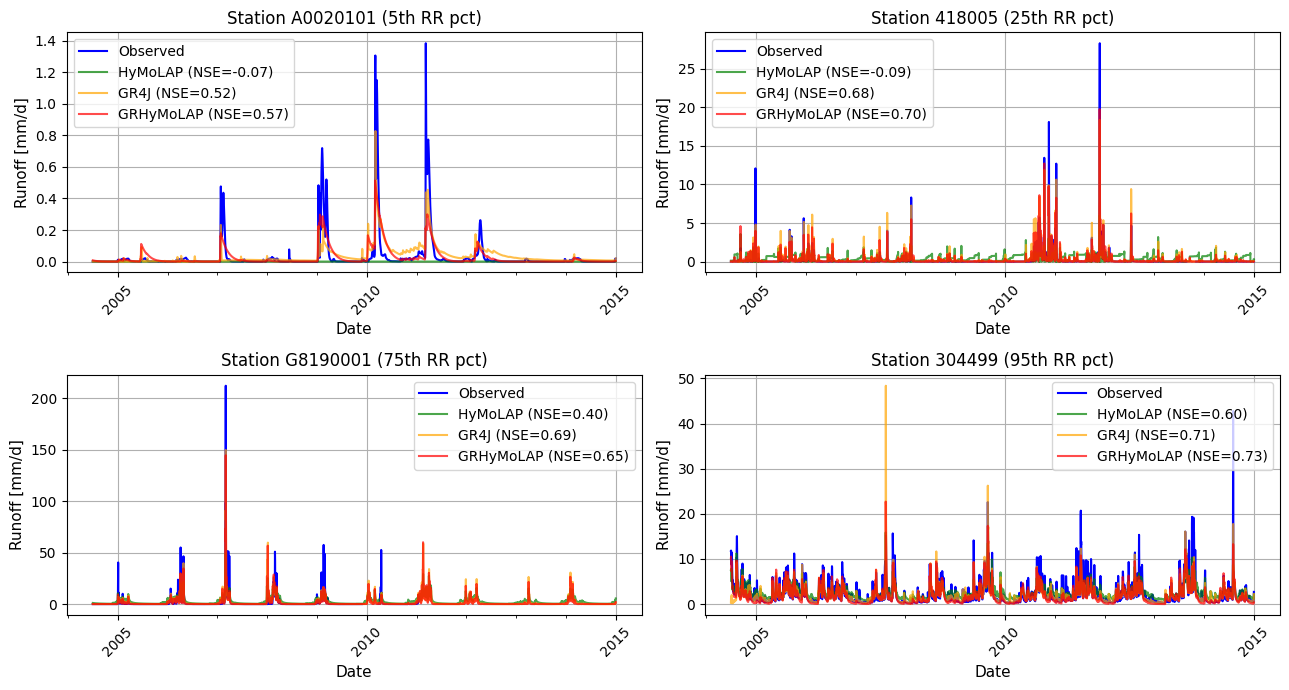

In [20]:
import matplotlib.dates as mdates

# Mapping for percentiles
station_percentiles = {
    "A0020101": "5th RR pct",
    "418005": "25th RR pct",
    "G8190001": "75th RR pct",
    "304499": "95th RR pct"
}

# Create a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=False)  # Do not share x to display all dates
axes = axes.flatten()  # For easier iteration

for ax, station_id in zip(axes, stations):
    Q_obs = Q[station_id].loc[start_date:end_date].to_numpy(float)
    dates_val = pd.date_range(start=start_date, end=end_date, freq="D")[b1:]

    # Observed series
    ax.plot(dates_val, Q_obs[b1:], label="Observed", color="blue")

    # --- HyMoLAP ---
    if station_id in results_HyMoLAP:
        nse_hy = results_HyMoLAP[station_id]["NSE_val"]
        ax.plot(
            dates_val,
            results_HyMoLAP[station_id]["Qsim_val"],
            label=f"HyMoLAP (NSE={nse_hy:.2f})",
            color="green",
            alpha=0.7
        )

    # --- GR4J ---
    if station_id in results_GR4J:
        nse_gr4j = results_GR4J[station_id]["NSE_val"]
        ax.plot(
            dates_val,
            results_GR4J[station_id]["Qsim_val"],
            label=f"GR4J (NSE={nse_gr4j:.2f})",
            color="orange",
            alpha=0.7
        )

    # --- GRHyMoLAP ---
    if station_id in results_GRHyMoLAP:
        nse_grhymolap = results_GRHyMoLAP[station_id]["NSE_val"]
        ax.plot(
            dates_val,
            results_GRHyMoLAP[station_id]["Qsim_val"],
            label=f"GRHyMoLAP (NSE={nse_grhymolap:.2f})",
            color="red",
            alpha=0.7
        )

    percentile_label = station_percentiles.get(station_id, "")
    ax.set_title(f"Station {station_id} ({percentile_label})", fontsize=12)
    ax.set_ylabel("Runoff [mm/d]", fontsize=11)
    ax.set_xlabel("Date", fontsize=11)
    ax.grid(True)
    ax.legend(fontsize=10)

    # Format the X-axis with yearly ticks
    ax.xaxis.set_major_locator(mdates.YearLocator(5))   # major tick every 5 years
    ax.xaxis.set_minor_locator(mdates.YearLocator(1))   # minor tick every year
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)

# Remove empty axes if fewer than 4 stations
for ax in axes[len(stations):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig("series_plot.jpeg", format='jpeg', dpi=700)
# files.download("series_plot.jpeg")
plt.show()


## X1: GR4J vs. GRHyMoLAP

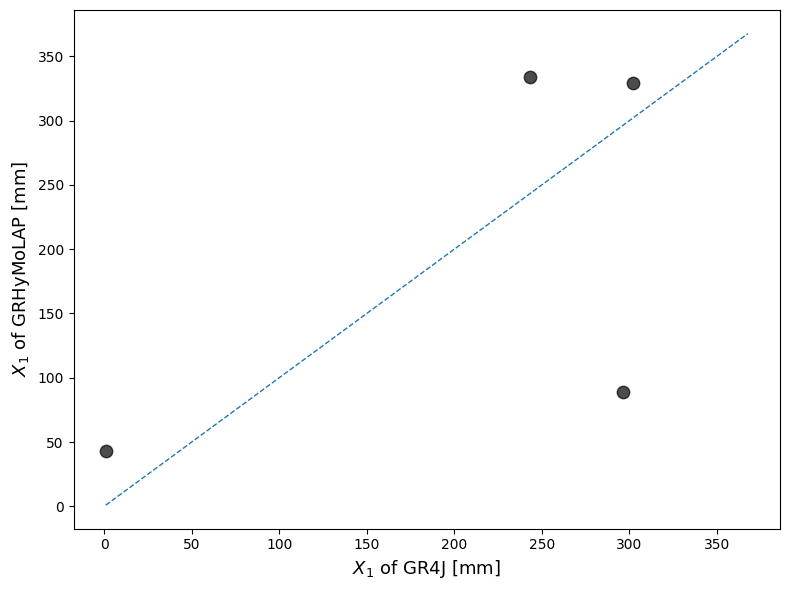

In [21]:
from scipy.stats import pearsonr

# ============================================
# Prepare X1 values for the selected stations
# ============================================
X1_GR4J_all = np.array([results_GR4J[s]["x1"] for s in stations])
X1_GRHyMoLAP_all = np.array([results_GRHyMoLAP[s]["params"][2] for s in stations])

# Global R²
r, _ = pearsonr(X1_GR4J_all, X1_GRHyMoLAP_all)
r2_global = r**2

# ============================================
# Scatter plot
# ============================================
plt.figure(figsize=(8,6))
plt.scatter(X1_GR4J_all, X1_GRHyMoLAP_all, s=80, color="black", alpha=0.7)

# 1:1 line
lims = [min(X1_GR4J_all.min(), X1_GRHyMoLAP_all.min())*0.9,
        max(X1_GR4J_all.max(), X1_GRHyMoLAP_all.max())*1.1]
plt.plot(lims, lims, '--', color='tab:blue', linewidth=1)

plt.xlabel(r"$X_1$ of GR4J [mm]", fontsize=13)
plt.ylabel(r"$X_1$ of GRHyMoLAP [mm]", fontsize=13)
#plt.title(f"Comparison of X1 across 10 selected basins (R² = {r2_global:.2f})", fontsize=14)
plt.grid(False)
plt.tight_layout()

plt.savefig("scatter_X1.jpeg", dpi=700)
#files.download("scatter_X1.jpeg")
plt.show()
